# routines

In [1]:
# === Standard libraries ===
import os
import json
import ast
import pickle
import warnings
import psutil

# === Scientific computing ===
import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error

# === EEG/MEG data handling ===
import mne

# === Plotting ===
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, ConnectionPatch
from matplotlib.colors import Normalize, LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
from scipy.interpolate import interp1d

# === Spectral analysis ===
from fooof import FOOOF

# === Progress bar ===
from tqdm import tqdm

# === Suppress specific warnings ===
warnings.filterwarnings("ignore", category=UserWarning)

SWEEP=100

C:\Users\verga\AppData\Local\Temp\ipykernel_13960\1179857691.py:28: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_exponential_black_half(ax, tau_rise=5, tau_decay=10, A=1.0, t_max=100, dt=0.1):
    """
    Disegna su 'ax' una funzione esponenziale smorzata:
    - salita tratteggiata nera con area tratteggiata nera
    - discesa nera piena (curva + area)
    - assi e griglia nascosti
    """
    t = np.arange(0, t_max, dt)
    t_peak = tau_rise * np.log(1 + tau_decay / tau_rise)
    y = A * (1 - np.exp(-t / tau_rise)) * np.exp(-t / tau_decay)

    mask_rise = t <= t_peak
    mask_decay = t > t_peak

    # Salita: curva tratteggiata + area tratteggiata
    ax.plot(t[mask_rise], -y[mask_rise], linestyle='--', color='black', linewidth=2)
    ax.fill_between(t[mask_rise], -y[mask_rise], color='none', edgecolor='black', hatch='///')

    # Discesa: curva piena + area piena
    ax.plot(t[mask_decay], -y[mask_decay], linestyle='-', color='black', linewidth=2)
    ax.fill_between(t[mask_decay], -y[mask_decay], color='black', alpha=0.5)

    # Rimuovi assi
    ax.axis('off')


def fit_constrained_poly(t_decay, y_decay, V_peak, degree=5, t_peak=15):
    t_shifted = t_decay - t_peak
    y_shifted = y_decay - V_peak
    X = np.vstack([t_shifted**i for i in range(1, degree + 1)]).T
    coeffs = np.linalg.lstsq(X, y_shifted, rcond=None)[0]
    return V_peak + X @ coeffs

# Funzioni di base
def generate_damped_oscillator(t, A=5.0, f=50.0, lambda_=25, t0=10):
    y = np.zeros_like(t)
    mask = t >= t0
    t_shifted = t[mask] - t0
    y[mask] = A * np.exp(-lambda_ * t_shifted / 1000) * np.sin(2 * np.pi * f * t_shifted / 1000)
    return y

def capacitive_artifact(t, t0, t_peak, tauRise, tauDecay, scale=-100):
    V0 = 1.0
    signal = np.zeros_like(t)
    for i, ti in enumerate(t):
        if ti < t0:
            signal[i] = 0
        elif ti < t_peak:
            signal[i] = V0 * (1 - np.exp(-(ti - t0) / tauRise))
        else:
            V_peak = V0 * (1 - np.exp(-(t_peak - t0) / tauRise))
            signal[i] = V_peak * np.exp(-(ti - t_peak) / tauDecay)
    return scale * signal

# Funzione carica-scarica
def carica_scarica(t, t0, t_peak, tauRise, tauDecay):
    V0 = 1.0
    signal = np.zeros_like(t)
    for i, ti in enumerate(t):
        if ti < t0:
            signal[i] = 0
        elif ti < t_peak:
            signal[i] = V0 * (1 - np.exp(-(ti - t0) / tauRise))
        else:
            V_peak = V0 * (1 - np.exp(-(t_peak - t0) / tauRise))
            signal[i] = V_peak * np.exp(-(ti - t_peak) / tauDecay)
    return signal


#def biexp(t, A, tau1, tau2, t0):
#    t_adj = np.clip(np.asarray(t) - t0, 0, None)
#    return A * (1 - np.exp(-t_adj / tau1)) * np.exp(-t_adj / tau2)

def biexp(t, A, tau1, tau2, t0):
    t_adj = np.clip(np.asarray(t) - t0, 0, None)
    # Limita gli argomenti dell'esponenziale per evitare overflow
    exp1 = np.exp(-np.clip(t_adj / tau1, 0, 700))  # evita valori troppo grandi
    exp2 = np.exp(-np.clip(t_adj / tau2, 0, 700))
    return A * (1 - exp1) * exp2


def exp_rise(t, A, tau, t0):
    t_adj = np.clip(np.asarray(t) - t0, 0, None)
    return A * (1 - np.exp(-t_adj / tau))

def exp_decay_constrained(t, tau, t_peak, t_full, y_full):
    interp = interp1d(t_full, y_full, kind='linear', bounds_error=False, fill_value="extrapolate")
    V_peak = float(interp(t_peak))
    return V_peak * np.exp(-(t - t_peak) / tau)

def add_scale_symbol(ax, dx=0.1, dy=0.1):
    # Coordinate in assi (0–1)
    x0, y0 = 0.88, 0.08  # in basso a destra
    ax.plot([x0, x0 + dx], [y0, y0], color='black', lw=1, transform=ax.transAxes, clip_on=False)
    ax.plot([x0, x0], [y0, y0 + dy], color='black', lw=1, transform=ax.transAxes, clip_on=False)
    ax.text(x0 + dx/2, y0 - 0.02, '100 ms', ha='center', va='top', transform=ax.transAxes)
    ax.text(x0 - 0.01, y0 + dy/2, '1', ha='right', va='center', transform=ax.transAxes)

def add_scale_symbol(ax, dx_ms=100, dy_uv=1, x0=0.65, y0=0.06):
    # Ottieni limiti assi per conversione unità → percentuali
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Conversione: da ms → unità assi (x)
    dx = dx_ms / (xlim[1] - xlim[0])

    # Conversione: da μV → unità assi (y)
    dy = dy_uv / (ylim[1] - ylim[0])

    # Posizione in basso a destra (coordinate normalizzate 0–1)
    #x0, y0 = 0.65, 0.06

    # Disegna le barrette
    ax.plot([x0, x0 + dx], [y0, y0], color='black', lw=1, transform=ax.transAxes, clip_on=False)
    ax.plot([x0, x0], [y0, y0 + dy], color='black', lw=1, transform=ax.transAxes, clip_on=False)

    # Etichette
    ax.text(x0 + dx / 2, y0 - 0.02, r'$100\ \mathrm{ms}$',
            ha='center', va='top', transform=ax.transAxes)
    ax.text(x0 - 0.01, y0 + dy / 2, r'$1\ \mu V$',
            ha='right', va='center', transform=ax.transAxes)


def base_axis(ax, t0=0):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(t0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_xlabel('')


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


In [3]:
plt.rcParams.update({
    "figure.dpi": 75,
    "font.size": 14,
    "font.weight": "bold",              # <--- AGGIUNTO
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False



# fig 1

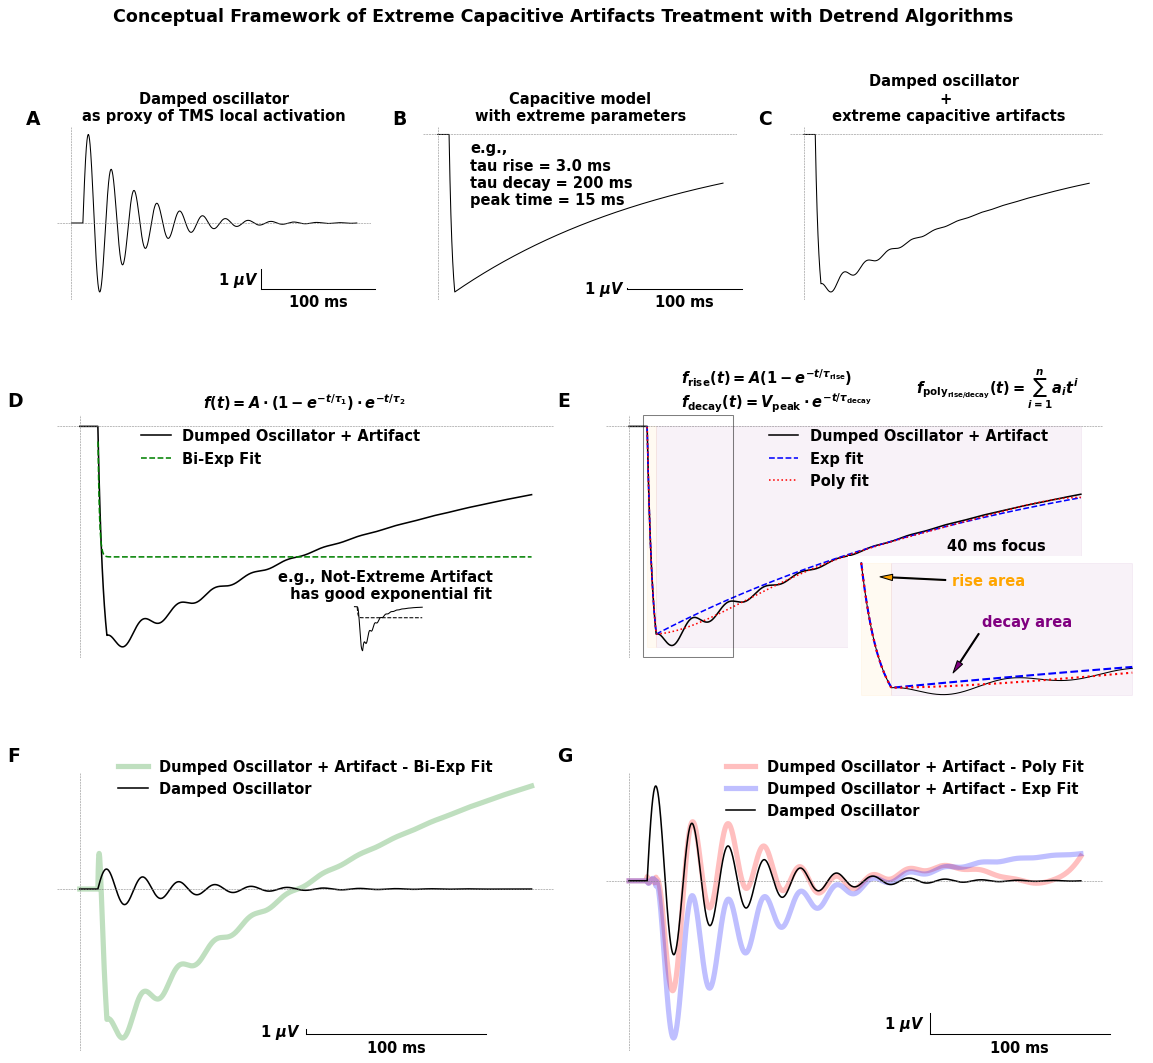

In [4]:
# Parametri temporali
t_start = 0
t_end = 250
dt = 0.1
t = np.arange(t_start, t_end, dt)

# Parametri oscillatore smorzato
A = 5.0
f = 50.0
lambda_ = 25
t0 = 10

# Oscillatore smorzato
y = np.zeros_like(t)
mask = t >= t0 
t_shifted = t[mask] - t0 
y[mask] = A * np.exp(-lambda_ * t_shifted / 1000) * np.sin(2 * np.pi * f * t_shifted / 1000)

# Parametri carica-scarica
t_peak = 15
tauRise = t_peak/5
tauDecay = 200
k = 100
charge = -carica_scarica(t, t0, t_peak, tauRise, tauDecay) * k
sum_signal = y + charge

mask_fit = t > t0
t_fit = t[mask_fit]
popt, _ = curve_fit(lambda t, A, tau1, tau2: biexp(t, A, tau1, tau2, t0),
                    t_fit, sum_signal[mask_fit], p0=[tauRise, 50, 100])
fit_curve = biexp(t_fit, *popt, t0)

# Fit rise/decay
mask_rise = (t >= t0) & (t < t_peak)
t_rise = t[mask_rise]
y_rise = sum_signal[mask_rise]

popt_rise, _ = curve_fit(lambda t, A, tau: exp_rise(t, A, tau, t0),
                         t_rise, y_rise, p0=[5, 10])
fit_rise = exp_rise(t_rise, *popt_rise, t0)
V_peak = exp_rise(t_peak, *popt_rise, t0)

mask_decay = t >= t_peak
t_decay = t[mask_decay]
y_decay = sum_signal[mask_decay]

popt_decay, _ = curve_fit(
    lambda t_local, tau: exp_decay_constrained(t_local, tau, t_peak, t, sum_signal),
    t_decay,
    y_decay,
    p0=[100]
)
fit_decay = exp_decay_constrained(t_decay, *popt_decay, t_peak, t, sum_signal)


# Fit polinomiale vincolato
degree = 5
t_decay_shifted = t_decay - t_peak
y_decay_shifted = y_decay - V_peak
X = np.vstack([t_decay_shifted**i for i in range(1, degree + 1)]).T
coeffs_constrained = np.linalg.lstsq(X, y_decay_shifted, rcond=None)[0]
interp = interp1d(t, sum_signal, kind='linear', bounds_error=False, fill_value="extrapolate")
fit_poly_decay = float(interp(t_peak)) + X @ coeffs_constrained
fit_poly_rise = np.polyval(np.polyfit(t_rise, y_rise, 3), t_rise)

# Residui
resid_biexp = np.zeros_like(t)
resid_biexp[mask_fit] = sum_signal[mask_fit] - fit_curve
resid_exp = np.zeros_like(t)
resid_exp[mask_rise] = sum_signal[mask_rise] - fit_rise
resid_exp[mask_decay] = sum_signal[mask_decay] - fit_decay
resid_poly = np.zeros_like(t)
resid_poly[mask_rise] = sum_signal[mask_rise] - fit_poly_rise
resid_poly[mask_decay] = sum_signal[mask_decay] - fit_poly_decay

# Errori
mse_biexp = mean_squared_error(sum_signal[mask_fit], fit_curve)
mae_biexp = mean_absolute_error(sum_signal[mask_fit], fit_curve)
mse_exp = mean_squared_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_rise, fit_decay]))
mae_exp = mean_absolute_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_rise, fit_decay]))
mse_poly = mean_squared_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_poly_rise, fit_poly_decay]))
mae_poly = mean_absolute_error(np.concatenate([y_rise, y_decay]), np.concatenate([fit_poly_rise, fit_poly_decay]))

# ─── Nuovo segnale con tauRise più lento (100 ms), decay invariato ───────
tauRise_inset = tauRise*20
tauDecay_inset = tauDecay*0.25
charge_inset = -carica_scarica(t, t0, t_peak*2, tauRise_inset, tauDecay_inset) * k
sum_signal_inset = y + charge_inset
mask_fit = t > t0
t_fit = t[mask_fit]
popt_inset, _ = curve_fit(lambda t, A, tau1, tau2: biexp(t, A, tau1, tau2, t0),
                          t_fit, sum_signal_inset[mask_fit], p0=[tauRise, 50, 100])
fit_curve_inset = biexp(t_fit, *popt_inset, t0)

fig = plt.figure(figsize=(18, 16))
fig.suptitle('Conceptual Framework of Extreme Capacitive Artifacts Treatment with Detrend Algorithms', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(
    3, 6,                # 3 righe, 6 colonne
    height_ratios=[1, 1.4, 1.6],
    width_ratios=[1]*6,  # 6 colonne tutte uguali
    hspace=0.5,
    wspace=0.4
)

# ─── Prima riga: 3 pannelli ciascuno largo 2 colonne ───────────
ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2:4])
ax2 = fig.add_subplot(gs[0, 4:6])

# ─── Terza riga: due pannelli ciascuno largo 3 colonne ────────────
ax_left  = fig.add_subplot(gs[2, 0:3])
ax_right = fig.add_subplot(gs[2, 3:6])

ax0.plot(t, y, color='black', lw=1)
ax1.plot(t, charge, color='black', lw=1)
ax2.plot(t, sum_signal, color='black', lw=1)
base_axis(ax0)
add_scale_symbol(ax0)
base_axis(ax1)
add_scale_symbol(ax1)
base_axis(ax2)
ax0.set_title('Damped oscillator\nas proxy of TMS local activation')
ax1.set_title('Capacitive model\nwith extreme parameters')
ax2.set_title('Damped oscillator \n + \n extreme capacitive artifacts')
ax1.text(0.05*3, 1-0.15, f'e.g.,', transform=ax1.transAxes, ha='left')
ax1.text(0.05*3, 0.9-0.15, f'tau rise = {tauRise} ms', transform=ax1.transAxes, ha='left')
ax1.text(0.05*3, 0.8-0.15, f'tau decay = {tauDecay} ms', transform=ax1.transAxes, ha='left')
ax1.text(0.05*3, 0.7-0.15, f'peak time = {t_peak} ms', transform=ax1.transAxes, ha='left')

# ─── Seconda riga: due pannelli ciascuno largo 3 colonne ────────────
ax3_left  = fig.add_subplot(gs[1, 0:3])
ax3_right = fig.add_subplot(gs[1, 3:6])
ax3_left.plot(t, sum_signal, color='k', label='Dumped Oscillator + Artifact')
ax3_left.plot(t_fit, fit_curve, '--', color='green', label='Bi-Exp Fit')
#ax3_left.set_title(
#    r'Not-Windowed Detrend (Bi-Exp Fit)')
ax3_left.text(0.7, 1.1, #1.25,
    r'$f(t) = A \cdot \left(1 - e^{-t/\tau_1} \right) \cdot e^{-t/\tau_2}$',
    transform=ax3_left.transAxes, va='top', ha='right'
)
ax3_left.legend(
    loc='upper center',
    bbox_to_anchor=(0.45, 1),
    ncol=1,
    frameon=False
)

#ax3_right.set_title('Windowed Detrend (Rise and Decay fits)', y=1)
base_axis(ax3_left)
#add_scale_symbol(ax3_left,  x0=0.9, y0=-0.1)
ax3_right.plot(t, sum_signal, color='k', label='Dumped Oscillator + Artifact')
ax3_right.plot(t_rise, fit_rise, '--', color='b', label='Exp fit')
ax3_right.plot(t_decay, fit_decay, '--', color='b', )
ax3_right.plot(t_rise, fit_poly_rise, ':', color='r', label='Poly fit')
ax3_right.plot(t_decay, fit_poly_decay, ':', color='r', )
#ax3_right.set_title('Windowed Detrend (separate fit for rise and decay)', y=1)
ax3_right.text(
    0.15, 1.2,
    r'$f_{\mathrm{rise}}(t) = A(1 - e^{-t/\tau_{\mathrm{rise}}})$',
    transform=ax3_right.transAxes,
    va='top', ha='left',
    color='k'
)
ax3_right.text(
    0.15, 1.1,
    r'$f_{\mathrm{decay}}(t) = V_{\mathrm{peak}} \cdot e^{-t/\tau_{\mathrm{decay}}}$',
    transform=ax3_right.transAxes,
    va='top', ha='left',
    color='k'
)
ax3_right.text(
    0.95, 1.2,
    r'$f_{\mathrm{poly}_\mathrm{rise/decay}}(t) = \sum_{i=1}^{n} a_i t^i$',
    transform=ax3_right.transAxes,
    va='top', ha='right'
)

y_min = np.min(sum_signal) - 0.5  # margine extra
ax3_right.fill(
    [t0, t_peak, t_peak, t0],
    [y_min, y_min, 0, 0],
    color='orange', alpha=0.05
)
ax3_right.fill(
    [t_peak, t[-1], t[-1], t_peak],
    [y_min, y_min, 0, 0],
    color='purple', alpha=0.05
)

base_axis(ax3_right)
ax3_right.legend(
    loc='upper left',
    bbox_to_anchor=(0.3, 1),
    ncol=1,
    frameon=False
)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
start_focus = 10 #t_peak
end_focus = 55 #t_peak + 50
mask_focus = (t >= start_focus) & (t <= end_focus)
t_focus = t[mask_focus]
signal_decay_focus = sum_signal[mask_focus]
fit_decay_focus = np.zeros_like(t_focus)
fit_poly_decay_focus = np.zeros_like(t_focus)
mask_decay_focus = t_focus >= t_peak
mask_rise_focus = t_focus < t_peak
fit_decay_focus[mask_decay_focus] = exp_decay_constrained(
    t_focus[mask_decay_focus], *popt_decay, t_peak, t, sum_signal
)

fit_poly_decay_focus[mask_decay_focus] = fit_poly_decay[(t_decay >= t_peak) & (t_decay <= end_focus)]
fit_decay_focus[mask_rise_focus] = exp_rise(t_focus[mask_rise_focus], *popt_rise, t0)
fit_poly_decay_focus[mask_rise_focus] = fit_poly_rise[(t_rise >= start_focus) & (t_rise <= t_peak)]
inset_y_min = np.min(signal_decay_focus) - 0.2
inset_decay = inset_axes(
    ax3_right,
    width="60%", height="60%",
    loc='upper right',
    bbox_to_anchor=(0.1, -0.55, 1, 1),
    bbox_transform=ax3_right.transAxes
)

inset_decay.fill_between(
    t_focus,
    inset_y_min,
    0,
    where=(t_focus < t_peak),
    color='orange',
    alpha=0.05
)
inset_decay.fill_between(
    t_focus,
    inset_y_min,
    0,
    where=(t_focus >= t_peak),
    color='purple',
    alpha=0.05
)
inset_decay.plot(t_focus, signal_decay_focus, color='k', lw=1, label='Dumped Oscillator + Artifact')
inset_decay.plot(t_focus, fit_decay_focus, '--', color='b', lw=2, label='Exp fit')
inset_decay.plot(t_focus, fit_poly_decay_focus, ':', color='r', lw=2, label='Poly fit')
inset_decay.set_title('40 ms focus')
inset_decay.set_xticks([])
inset_decay.set_yticks([])
for spine in inset_decay.spines.values():
    spine.set_visible(False)
ax3_right.indicate_inset_zoom(inset_decay, edgecolor='k', linewidth=1, alpha=0.5)

idx_rise = np.where((t >= t0 + 5) & (t <= t0 + 15))[0][0]
idx_decay = np.where((t >= t0 + 40) & (t <= t0 + 60))[0][0]
x_rise, y_rise = t[idx_rise], sum_signal_inset[idx_rise]
x_decay, y_decay = t[idx_decay], sum_signal_inset[idx_decay]

# Annotazione per la zona arancione (rise)
inset_decay.annotate('rise area', xy=(x_rise-2.5, y_rise-5),
                  xytext=(x_rise + 10, y_rise-10),
                  arrowprops=dict(facecolor='orange', edgecolor='black',
                                  shrink=0.05, width=1, headwidth=6),
                  color='orange')

# Annotazione per la zona viola (decay)
inset_decay.annotate('decay area', 
                     xy=(x_decay-25, y_decay-50),
                  xytext=(x_decay-20, y_decay-20),
                  arrowprops=dict(facecolor='purple', edgecolor='black',
                                  shrink=0.05, width=1, headwidth=6),
                  color='purple')

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Crea inset in basso a destra di ax3
inset_ax = inset_axes(ax3_left, width="15%", height="20%", loc='lower right', borderpad=2, bbox_to_anchor=(-0.05*4, -0.1, 1, 1), bbox_transform=ax3_left.transAxes)
inset_ax.plot(t_fit, fit_curve_inset, '--', color='black', lw=1)
inset_ax.plot(t, sum_signal_inset, color='k', lw=1, label='Artifacted Damped Oscillator')
inset_ax.set_title('e.g., Not-Extreme Artifact \n has good exponential fit')
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.set_xticklabels([])
inset_ax.set_yticklabels([])
for spine in inset_ax.spines.values():
    spine.set_visible(False)

# PLOT RESIDUI
#ax_left.set_title('Detrend output: Dumped Oscillator + Artifact - Fit', y=1.1, x=0.35)
ax_left.plot(t, resid_biexp, '-', label=f'Dumped Oscillator + Artifact - Bi-Exp Fit', color='green', linewidth=5, alpha=.25)
ax_left.plot(t, y, '-', c='k', alpha=1, label='Damped Oscillator')
ax_left.set_xlabel(' ')
base_axis(ax_left)
add_scale_symbol(ax_left, x0=0.5)
ax_left.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.1),
    ncol=1,
    frameon=False
)

#ax_right.plot(t, resid_exp, '-', label=f'exp\nMSE={mse_exp:.2f}, MAE={mae_exp:.2f}', color='b')
#ax_right.plot(t, resid_poly, '-', label=f'poly\nMSE={mse_poly:.2f}, MAE={mae_poly:.2f}', color='r')
ax_right.plot(t, resid_poly, '-', label='Dumped Oscillator + Artifact - Poly Fit',  color='r', linewidth=5, alpha=.25)
ax_right.plot(t, resid_exp, '-', label='Dumped Oscillator + Artifact - Exp Fit', color='b', linewidth=5, alpha=.25)
ax_right.plot(t, y, '-', c='k', alpha=1, label='Damped Oscillator')
ax_right.set_title(' ')
ax_right.set_xlabel(' ')
base_axis(ax_right)
add_scale_symbol(ax_right)

ax_right.legend(
    loc='upper center',
    bbox_to_anchor=(0.6, 1.1),
    ncol=1,
    frameon=False
)

# Lettere nei pannelli principali (in alto a sinistra)
for i, ax in enumerate([ax0, ax1, ax2, ax3_left, ax3_right, ax_left, ax_right]):
    ax.text(-0.1, 1.1, chr(65 + i), transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left')

plt.tight_layout()
# Salvataggio
os.makedirs("./paperFigures", exist_ok=True)
fig.savefig("./paperFigures/FigureA.pdf", format="pdf", bbox_inches="tight")
fig.savefig("./paperFigures/FigureA.png", format="png", bbox_inches="tight")
fig.savefig("./paperFigures/FigureA.svg", format="svg", bbox_inches="tight")

# fig 2.1

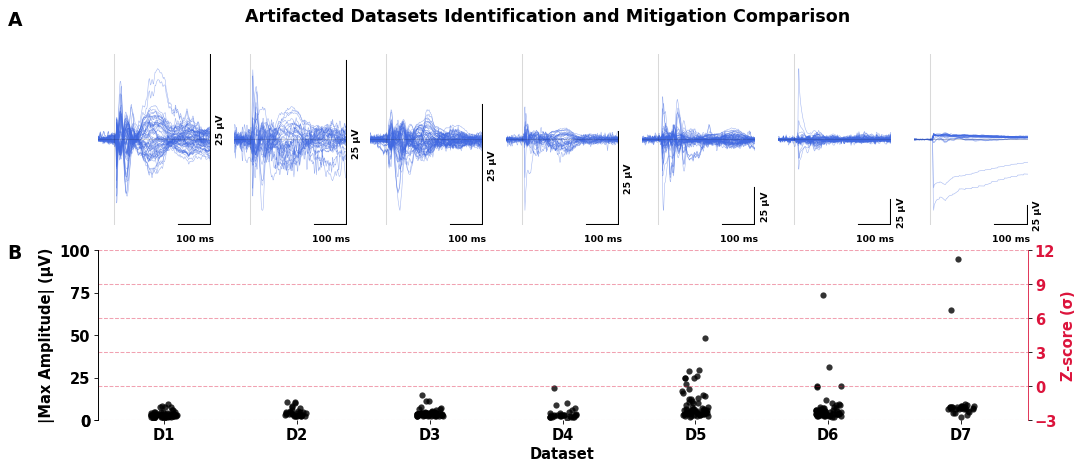

In [5]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

file_paths = [
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\1.Easycap+Brainamp+Nexstim\False_CX_nowind_alpha_nowind_alpha\6.pkls\prova_Betta_0001_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\4.Easycap+EBNeuro_amp+Nexstim\False_Gaussian_CX_wind_poly_lagrange_wind_poly_3\6.pkls\TEPEMISFEROSXSTIMNETXTIMEASYCUP_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\2.Easycap+Brainamp+EBNeuro_stim\2025_02_26_103050_experiment-CX\6.pkls\prova_Betta_0002_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\3.Easycap+EBNeuro_amp+EBNeuro_stim\old\20250122183419-TEPEMISFEROSXEASYCUP-experiment\6.pkls\TEPEMISFEROSXEASYCUP_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\PAPER\F_G_ICA_ICA\6.pkls\CE20_07_08_2019_000004_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\PAPER\F_G_ICA_ICA\6.pkls\CE17_18_07_19_000003_epochs.pkl",
    r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\PAPER\T_G_ICA_ICA\6.pkls\prova_Mario_0003_epochs.pkl"
]

dataset_names = ["D1", "D2", "D3", "D4", "D5", "D6", "D7"]

fig = plt.figure(figsize=(16, 6.33))
fig.suptitle('Artifacted Datasets Identification and Mitigation Comparison', fontweight='bold', y=0.98)

gs = fig.add_gridspec(2, len(file_paths), height_ratios=[2, 2], hspace=0.15)

max_amplitudes = []
tep_axes = []
bar_heights = [25] * len(file_paths)

# === LETTERE PANNELLI ===
fig.text(0.05, 0.94, 'A', fontsize=18, fontweight='bold')  # Pannello B
fig.text(0.05, 0.45, 'B', fontsize=18, fontweight='bold')  # Pannello B
#fig.text(1, 0.145, 'STAGE 0', fontsize=18, fontweight='bold')  # Pannello B


# === PANNELLI TEP ===
for idx, (path, name) in enumerate(zip(file_paths, dataset_names)):
    with open(path, 'rb') as f:
        data = pickle.load(f)

    data_array = data.get_data(copy=False)
    mean_data = np.mean(data_array, axis=0)
    times = data.times

    ax = fig.add_subplot(gs[0, idx])
    tep_axes.append(ax)

    # µV conversion
    scale = 1e6 if name != 'D2' else 1
    scaled_data = mean_data * scale

    # Plot
    for ch in scaled_data:
        ax.plot(times, ch, color='royalblue', alpha=0.5, linewidth=0.5)

    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.15)
    ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.15)

    # Limiti
    peak = np.max(np.abs(scaled_data))
    ylim = (-1.2 * peak, 1.2 * peak)
    ax.set_ylim(ylim)
    ax.set_xlim(-0.05, 0.3)

    # === BARRETTE TEMPORALI ===
    amp_bar = bar_heights[idx]
    t_end = ax.get_xlim()[1]
    t_start = t_end - 0.1
    
    ylim = ax.get_ylim()
    neg_limit = ylim[0]  # è il valore negativo massimo (es. -40)
    y_bar = 1 * neg_limit  # posizionamento a 80% verso il basso
    ax.plot([t_start, t_end], [y_bar, y_bar], 'k', lw=2)

    ax.plot([t_end, t_end], [y_bar, y_bar + amp_bar], 'k', lw=2)

    from matplotlib.transforms import offset_copy
    
    ax.annotate('100 ms',
                xy=((t_start + t_end) / 2, y_bar), xycoords='data',
                textcoords='offset points', xytext=(0, -10),
                ha='center', va='top', fontsize=9)
    
    ax.annotate(f'{amp_bar} µV',
                xy=(t_end, y_bar + amp_bar / 2), xycoords='data',
                textcoords='offset points', xytext=(5, 0),
                ha='left', va='center', fontsize=9, rotation='vertical')


    
    # Axes cleanup
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
    #ax.set_title(name)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for ch_idx in range(mean_data.shape[0]):
        signal = mean_data[ch_idx] * scale
        max_val = np.max(np.abs(signal))
        max_amplitudes.append({"Dataset": name, "Channel": ch_idx, "MaxAmplitude": max_val})

# === SWARM PLOT ===
df_max = pd.DataFrame(max_amplitudes)

# Calcolo Z-score intra-dataset per ciascun dato
df_max["ZscoreIntra"] = df_max.groupby("Dataset")["MaxAmplitude"].transform(zscore).abs()
df_max["ZscoreGlobal"] = zscore(df_max["MaxAmplitude"])

# === SWARM PLOT AMPLITUDINI ===
ax_swarm = fig.add_subplot(gs[1, :])
sns.stripplot(data=df_max, x="Dataset", y="MaxAmplitude", ax=ax_swarm,
              size=3*2, color="black", alpha=0.8)
ax_swarm.set_ylabel("|Max Amplitude| (µV)")
ax_swarm.spines['top'].set_visible(False)
ax_swarm.spines['right'].set_visible(False)
ax_swarm.set_ylim(0, 100)
ax_swarm.set_yticks([0, 0, 25, 50, 75, 100])
ax_swarm.spines['bottom'].set_visible(False)

# === SWARM Z-SCORE SECONDARY AXIS ===
ax_z = ax_swarm.twinx()
sns.swarmplot(data=df_max, x="Dataset", y="ZscoreGlobal", ax=ax_z,
              size=3, color="crimson", alpha=0)
ax_z.set_ylabel("Z-score", color="crimson")
ax_z.tick_params(axis='y', labelcolor='crimson')
ax_z.spines['top'].set_visible(False)
ax_z.spines['bottom'].set_visible(False)
ax_z.spines['right'].set_color("crimson")
ax_z.set_ylabel("Z-score (σ)", color="crimson")
ax_z.set_yticks([-3, 0, 3, 6, 9, 12])
for level in [-3, 0, 3, 6, 9, 12]:
    ax_z.axhline(level, linestyle='--', color='crimson', alpha=0.4, linewidth=1)


# === SALVATAGGIO ===
save_dir = r"./paperFigures"
os.makedirs(save_dir, exist_ok=True)

fig.savefig(os.path.join(save_dir, "Figure_B.png"), bbox_inches="tight")
fig.savefig(os.path.join(save_dir, "Figure_B.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(save_dir, "Figure_B.svg"), bbox_inches="tight")
plt.show()


# fig 2.2

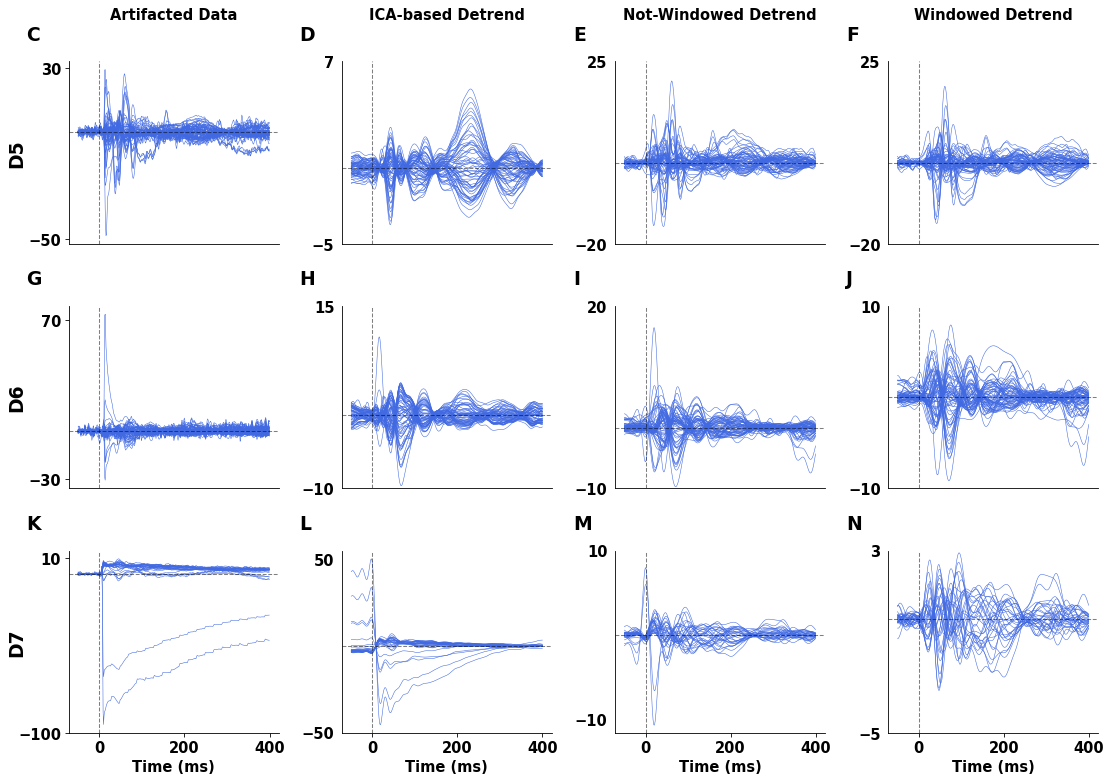

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

def round_to_five_or_ten(x):
    """Arrotonda a multipli di 5 o 10 per miglior leggibilità."""
    abs_x = abs(x)
    if abs_x <= 10:
        return np.sign(x) * (5 * round(abs_x / 5))
    else:
        return np.sign(x) * (10 * round(abs_x / 10))

panel_configs = [

    {
        "subject": "D5",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\PAPER\F_G_ICA_ICA\6.pkls\CE20_07_08_2019_000004_epochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\PAPER\F_G_ICA_ICA\6.pkls\CE20_07_08_2019_000004_postICA_final.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\PAPER\T_F_nowind_biexp_nowind_biexp\6.pkls\CE20_07_08_2019_000004_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\PAPER\F_G_wind_poly_lagrange_wind_poly_3\6.pkls\CE20_07_08_2019_000004_detrendedEpochs.pkl",

        ]
    },
    {
        "subject": "D6",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\PAPER\F_G_ICA_ICA\6.pkls\CE17_18_07_19_000003_epochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\PAPER\F_G_ICA_ICA\6.pkls\CE17_18_07_19_000003_postICA_final.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\PAPER\T_F_nowind_biexp_nowind_biexp\6.pkls\CE17_18_07_19_000003_detrendedEpochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\PAPER\F_G_wind_poly_lagrange_wind_poly_3\6.pkls\CE17_18_07_19_000003_detrendedEpochs.pkl",

        ]
    },
    {
        "subject": "D7",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\PAPER\T_G_ICA_ICA\6.pkls\prova_Mario_0003_epochs.pkl",
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\PAPER\T_G_ICA_ICA\6.pkls\prova_Mario_0003_postICA_final.pkl",
             r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\PAPER\T_F_nowind_biexp_nowind_biexp\6.pkls\prova_Mario_0003_detrendedEpochs.pkl",
             r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\PAPER\F_G_wind_poly_lagrange_wind_poly_3\6.pkls\prova_Mario_0003_detrendedEpochs.pkl",

        ]
    },

]

col_titles = ["Artifacted Data", "ICA-based Detrend", "Not-Windowed Detrend", "Windowed Detrend"]
color_line = 'royalblue'

def base_axis(ax):
    ax.spines[:].set_visible(False)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(t0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_xlabel('')

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 11), sharey=False, sharex=False)

for row_idx, subject_data in enumerate(panel_configs):
    subject = subject_data["subject"]
    file_paths = subject_data["file_paths"]

    for col_idx, file_path in enumerate(file_paths):
        with open(file_path, 'rb') as f:
            data = pickle.load(f)

        from scipy.signal import butter, filtfilt
        
        def bandpass_filter(data, srate, lowcut=1, highcut=30, order=4):
            nyq = 0.5 * srate
            low = lowcut / nyq
            high = highcut / nyq
            b, a = butter(order, [low, high], btype='band')
            return filtfilt(b, a, data, axis=-1)
        
        if col_titles[col_idx] not in ("Artifacted Data", "ICA-based Detrend"):
            data_array = data.get_data(copy=False)
            srate = data.info['sfreq']
            data_array = bandpass_filter(data_array, srate, order=4 if subject!='D5' else 1)
        else:
            data_array = data.get_data(copy=False)

        
        mean_data = np.mean(data_array, axis=0)
        times_ms = data.times * 1000
        mask = times_ms >= -50
        mean_data = mean_data[:, mask]
        times_ms = times_ms[mask]

        ax = axes[row_idx, col_idx]
        ax = axes[row_idx, col_idx]
        
        for ch in mean_data:

            ax.plot(times_ms, ch * 1e6, color=color_line, alpha=1, linewidth=0.5)

        ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=.5)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=.5)
        # Lettera del pannello (partendo da C)
        panel_idx = row_idx * 4 + col_idx  # 4 colonne
        panel_letter = chr(ord('C') + panel_idx)
        ax.text(-0.2, 1.2, f'{panel_letter}', transform=ax.transAxes, fontsize=18, fontweight='bold',
         va='top', ha='left')

        if row_idx == 0:
            ax.set_title(col_titles[col_idx], y=1.2)

        if col_idx == 0:
            ax.text(-0.2, 0.5, subject, transform=ax.transAxes, fontsize=18, fontweight='bold',
                     va='center', ha='right', rotation=90)

        # Arrotondamento tick Y
        y_vals = mean_data * 1e6
        y_min_raw = np.min(y_vals)
        y_max_raw = np.max(y_vals)
        if y_min_raw == y_max_raw:
            yticks = [0]
        else:
            y_min = round_to_five_or_ten(np.floor(y_min_raw))
            y_max = round_to_five_or_ten(np.ceil(y_max_raw))
            yticks = [y_min, y_max] if y_min < 0 and y_max > 0 else sorted(set([y_min, y_max]))
        ax.set_yticks(yticks)

        if row_idx != 2:
            ax.set_xticks([])
            ax.set_xlabel("")
        else:
            ax.set_xlabel("Time (ms)")

        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

        if col_idx != 0:
            ax.yaxis.set_ticks_position('none')
        
        # Vincolo asse Y per i pannelli 5, 6, 7 (seconda riga, colonne 1-3)
        if row_idx == 0 and col_idx in [1]:
            ax.set_ylim(-5, 7)
            ax.set_yticks([-5, 7])
            
        if row_idx == 0 and col_idx in [2,3]:
            ax.set_ylim(-20, 25)
            ax.set_yticks([-20, 25])
            
        if row_idx == 1 and col_idx in [1]:
            ax.set_ylim(-10, 15)
            ax.set_yticks([-10, 15])
            
        if row_idx == 1 and col_idx in [2]:
            ax.set_ylim(-10, 20)
            ax.set_yticks([-10, 20])
            
        if row_idx == 1 and col_idx in [3]:
            ax.set_ylim(-10, 10)
            ax.set_yticks([-10, 10])

        if row_idx == 2 and col_idx in [3]:
            ax.set_ylim(-5, 3)
            ax.set_yticks([-5, 3])

        #base_axis(ax)

plt.tight_layout(rect=[0, 0, 1, 0.97])


# Salvataggio
os.makedirs("./paperFigures", exist_ok=True)
fig.savefig("./paperFigures/FigureC.pdf", format="pdf", bbox_inches="tight", dpi=300)
fig.savefig("./paperFigures/FigureC.png", format="png", bbox_inches="tight", dpi=300)
fig.savefig("./paperFigures/FigureC.svg", format="svg", bbox_inches="tight", dpi=300)


# supporting 1.1

In [7]:
# Grid definition
tauRise_vals = np.linspace(1, 50, SWEEP)
tauDecay_vals = np.linspace(25, 250, SWEEP)
mse_grid = np.zeros((len(tauRise_vals), len(tauDecay_vals)))
charge_matrix = [[None for _ in tauDecay_vals] for _ in tauRise_vals]

# Grid search
for i, tauR in enumerate(tauRise_vals):
    for j, tauD in enumerate(tauDecay_vals):
        charge_test = -carica_scarica(t, t0, t_peak, tauR, tauD) * k
        sum_signal_test = charge_test
        charge_matrix[i][j] = sum_signal_test

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                popt_test, _ = curve_fit(biexp, t_fit, sum_signal_test[mask_fit], p0=[1.0, 50, 100, t0])
                fit_test = biexp(t_fit, *popt_test)
                mse_grid[i, j] = mean_squared_error(sum_signal_test[mask_fit], fit_test)
            except RuntimeError:
                mse_grid[i, j] = 1e4






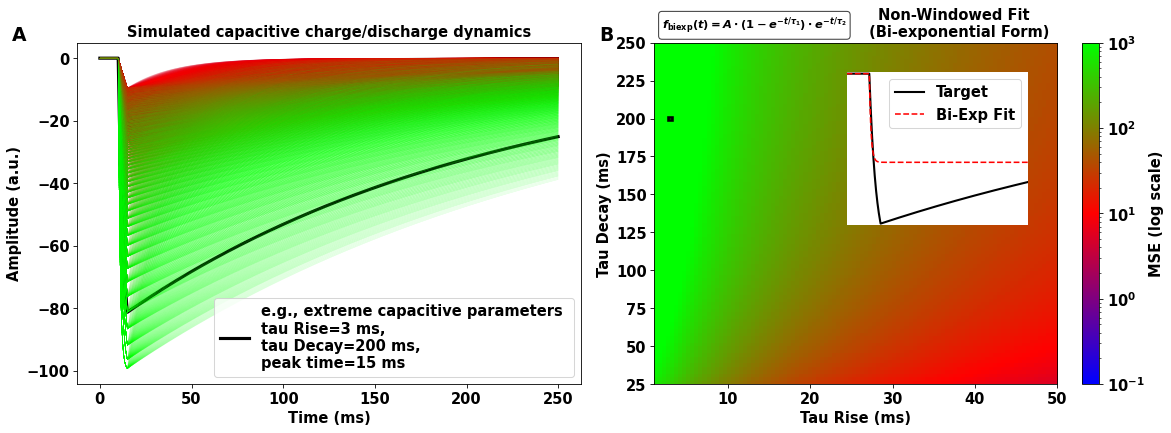

In [8]:
# Normalize MSE
#norm_mse = LogNorm(vmin=np.nanmin(mse_grid[mse_grid > 0]), vmax=np.nanmax(mse_grid))
norm_mse = LogNorm(vmin=1e-1, vmax=1e3)

# Setup figure
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
cmap = plt.colormaps['brg']

# Etichette pannelli
axs[0].text(-0.1, 1.05, 'A', transform=axs[0].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
axs[1].text(-0.1, 1.05, 'B', transform=axs[1].transAxes, fontsize=18, fontweight='bold', va='top', ha='right')

# Pannello A – Simulated signals
axs[0].set_title('Simulated capacitive charge/discharge dynamics')
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('Amplitude (a.u.)')

# Selezione 10% + target
valid_indices = [(i, j) for i in range(len(tauRise_vals)) for j in range(len(tauDecay_vals))]
np.random.seed(42)
chosen_indices = np.random.choice(len(valid_indices), size=int(len(valid_indices) * 1), replace=False)
selected_indices = {valid_indices[i] for i in chosen_indices}

# Target
i_target = np.argmin(np.abs(tauRise_vals - 3))
j_target = np.argmin(np.abs(tauDecay_vals - 200))
selected_indices.add((i_target, j_target))
target_signal = charge_matrix[i_target][j_target]

# Plot pannello A
for i, j in selected_indices:
    sig = charge_matrix[i][j]
    if sig is not None:
        mse_val = mse_grid[i, j]
        if (i, j) == (i_target, j_target):
            axs[0].plot(t, sig, color='black', linewidth=3,
                        label='e.g., extreme capacitive parameters \ntau Rise=3 ms, \ntau Decay=200 ms, \npeak time=15 ms')
        else:
            color = cmap(norm_mse(mse_val))
            alpha = 1 if mse_val < 0.05 else 0.15
            lw = 1 if mse_val < 0.05 else 0.5
            axs[0].plot(t, sig, color=color, alpha=alpha, linewidth=lw)
axs[0].legend()

# ⬛ INSET con fit bi-esponenziale
inset_ax = inset_axes(axs[1], width="45%", height="45%", loc='upper right', borderpad=2)
#inset_ax = axs[1].inset_axes([0.3, -1, 0.45, 0.45])

popt, _ = curve_fit(lambda t, A, tau1, tau2: biexp(t, A, tau1, tau2, t0),
                    t[t > t0], target_signal[t > t0], p0=[5, 20, 100])

fit_biexp = biexp(t, *popt, t0)

# Plot inset
inset_ax.plot(t, target_signal, label='Target', color='black', linewidth=2)
label_text = (
    r'Bi-Exp Fit'
)

inset_ax.plot(t, fit_biexp, label=label_text, color='red', linestyle='--')

inset_ax.set_xlim(0, 80)
inset_ax.set_ylim(np.min(target_signal) - 1, np.max(target_signal) + 1)
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.set_xticklabels([])
inset_ax.set_yticklabels([])
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')
inset_ax.set_title('')
inset_ax.legend()
#.set_visible(False)
for spine in inset_ax.spines.values():
    spine.set_visible(False)

# Pannello B – Heatmap MSE
im = axs[1].imshow(mse_grid.T, origin='lower', aspect='auto',
                   extent=[tauRise_vals[0], tauRise_vals[-1], tauDecay_vals[0], tauDecay_vals[-1]],
                   cmap=cmap, norm=norm_mse)
axs[1].text(0.02, 1.02,
    r"$f_{\mathrm{biexp}}(t) = A \cdot (1 - e^{-t/\tau_1}) \cdot e^{-t/\tau_2}$",
    transform=axs[1].transAxes,
    fontsize=11, va='bottom', ha='left',
    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.75))
axs[1].set_xlabel('Tau Rise (ms)')
axs[1].set_ylabel('Tau Decay (ms)')
axs[1].set_title("Non-Windowed Fit \n (Bi-exponential Form)", x=0.75)

fig.colorbar(im, ax=axs[1], label='MSE (log scale)')

# Rettangolo nero
dx = tauRise_vals[1] - tauRise_vals[0]
dy = tauDecay_vals[1] - tauDecay_vals[0]
x_rect = tauRise_vals[i_target] - dx / 2
y_rect = tauDecay_vals[j_target] - dy / 2
axs[1].add_patch(Rectangle((x_rect, y_rect), dx, dy,
                           linewidth=2.5, edgecolor='black', facecolor='none'))

# Salvataggio
plt.tight_layout()
os.makedirs("./paperFigures", exist_ok=True)
fig.savefig("./paperFigures/Supporting_FigureA_1.pdf", format="pdf", bbox_inches="tight")
fig.savefig("./paperFigures/Supporting_FigureA_1.png", format="png", bbox_inches="tight")
fig.savefig("./paperFigures/Supporting_FigureA_1.svg", format="svg", bbox_inches="tight")
plt.show()


# supporting 1.2

In [9]:

# Parametri
t0, t_peak, dt = 10, 15, 0.1
t = np.arange(0, 250, dt)
oscillator = generate_damped_oscillator(t)
tauRise_vals = np.linspace(1, 50, SWEEP)
tauDecay_vals = np.linspace(25, 250, SWEEP)

MSE_biexp = np.zeros((len(tauRise_vals), len(tauDecay_vals)))
MSE_exp = np.zeros((len(tauRise_vals), len(tauDecay_vals)))
MSE_poly = np.zeros((len(tauRise_vals), len(tauDecay_vals)))
charge_matrix_ = [[None for _ in range(len(tauDecay_vals))] for _ in range(len(tauRise_vals))]

# Loop per fit
for i, tauRise in enumerate(tauRise_vals):
    for j, tauDecay in enumerate(tauDecay_vals):
        artifact = capacitive_artifact(t, t0, t_peak, tauRise, tauDecay)
        signal = oscillator + artifact
        charge_matrix_[i][j] = signal
        mask_fit = t > t0
        t_fit = t[mask_fit]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                popt_biexp, _ = curve_fit(lambda t, A, tau1, tau2: biexp(t, A, tau1, tau2, t0), t_fit, signal[mask_fit], p0=[5, 20, 100], maxfev=10000)
                fit_biexp = biexp(t_fit, *popt_biexp, t0)
                MSE_biexp[i, j] = mean_squared_error(oscillator[mask_fit], signal[mask_fit] - fit_biexp)
            except:
                MSE_biexp[i, j] = 1e3
    
            try:
                mask_rise = (t >= t0) & (t < t_peak)
                t_rise = t[mask_rise]
                y_rise = signal[mask_rise]
                popt_rise, _ = curve_fit(lambda t, A, tau: exp_rise(t, A, tau, t0), t_rise, y_rise, p0=[5, 10])
                fit_r = exp_rise(t_rise, *popt_rise, t0)
                V_peak = exp_rise(t_peak, *popt_rise, t0)
        
                mask_decay = t >= t_peak
                t_decay = t[mask_decay]
                y_decay = signal[mask_decay]
                popt_d, _ = curve_fit(
                lambda t, tau: exp_decay_constrained(t, tau, t_peak, t, y_decay),  # t come t_full e y_decay come y_full
                t_decay, y_decay, p0=[100]
                )
                fit_d = exp_decay_constrained(t_decay, *popt_d, t_peak, t_decay, y_decay)
        
                fit_full_exp = np.zeros_like(t)
                fit_full_exp[mask_rise] = fit_r
                fit_full_exp[mask_decay] = fit_d
        
                MSE_exp[i, j] = mean_squared_error(oscillator, signal - fit_full_exp)
            except:
                MSE_exp[i, j] = 1e3
    
            try:
                fit_poly_r = np.polyval(np.polyfit(t_rise, y_rise, 3), t_rise)
                fit_poly_d = fit_constrained_poly(t_decay, y_decay, V_peak, degree=5, t_peak=t_peak)
    
                fit_full_poly = np.zeros_like(t)
                fit_full_poly[mask_rise] = fit_poly_r
                fit_full_poly[mask_decay] = fit_poly_d
    
                MSE_poly[i, j] = mean_squared_error(oscillator, signal - fit_full_poly)
            except:
                MSE_poly[i, j] = 1e3



(0, 1) Non-Windowed Detrend 
 (Bi-exponential Form)
(1, 0) Windowed Detrend 
 (Exponential Form)
(1, 1) Windowed Detrend 
 (Polynomial Form)


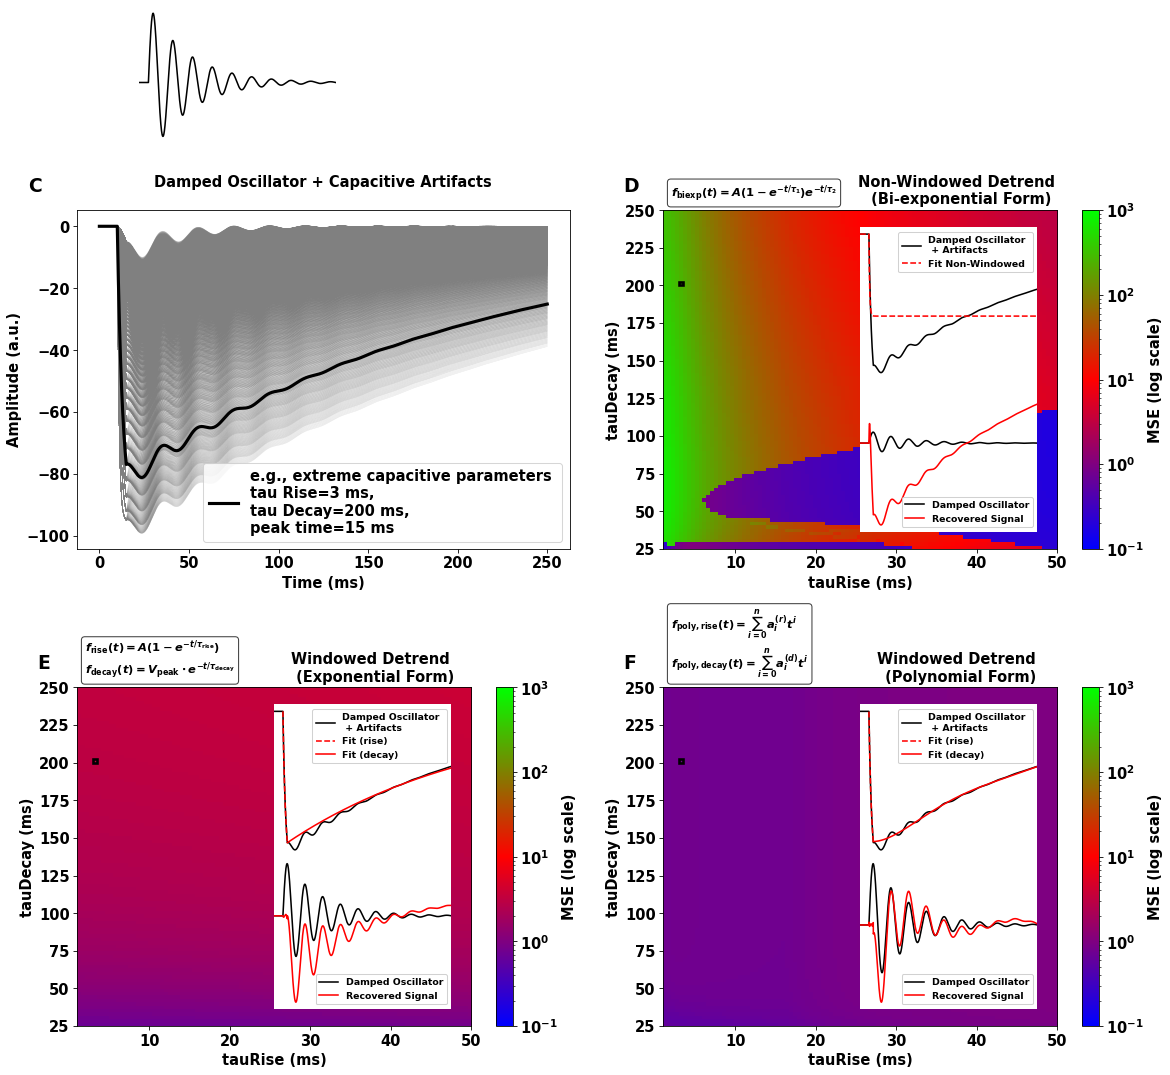

In [10]:
# === FIGURA ===
#vmin = np.nanmin([MSE_biexp, MSE_exp, MSE_poly])
#vmax = np.nanpercentile([MSE_biexp, MSE_exp, MSE_poly], 100)
#norm_mse = LogNorm(vmin=max(vmin, 1e-3), vmax=vmax)

fig, axs = plt.subplots(2, 2, figsize=(16, 15))
heatmaps = [MSE_biexp, MSE_exp, MSE_poly]
titles = ["Non-Windowed Detrend \n (Bi-exponential Form)",
          "Windowed Detrend \n (Exponential Form)",
          "Windowed Detrend \n (Polynomial Form)"]
positions = [(0, 1), (1, 0), (1, 1)]

# Segnale target
target_i = np.argmin(np.abs(tauRise_vals - 3))
target_j = np.argmin(np.abs(tauDecay_vals - 200))
target_signal = charge_matrix_[target_i][target_j]

# Plot dei segnali generati
for row in charge_matrix_:
    for sig in row:
        axs[0, 0].plot(t, sig, color='gray', alpha=0.2, linewidth=0.5)
axs[0, 0].plot(t, target_signal, color='black', linewidth=3,
               label='e.g., extreme capacitive parameters \ntau Rise=3 ms, \ntau Decay=200 ms, \npeak time=15 ms')
axs[0, 0].set_title("Damped Oscillator + Capacitive Artifacts", y=1.05)
axs[0, 0].set_xlabel("Time (ms)")
axs[0, 0].set_ylabel("Amplitude (a.u.)")
axs[0, 0].legend(loc='lower right')

# Coordinate rettangolo
x_rect = tauRise_vals[target_i]
y_rect = tauDecay_vals[target_j]
dx = tauRise_vals[1] - tauRise_vals[0]
dy = tauDecay_vals[1] - tauDecay_vals[0]

insetO = axs[0, 0].inset_axes([0.125, 1.2, 0.4, 0.4])
insetO.plot(t, oscillator, label="Damped Oscillator", color='black')
insetO.set_xlim(0, 200)
#insetO.legend()
insetO.set_xticks([])
insetO.set_yticks([])
insetO.set_xticklabels([])
insetO.set_yticklabels([])
insetO.set_xlabel('')
insetO.set_ylabel('')
insetO.set_title('')
insetO.spines['right'].set_visible(False)
insetO.spines['top'].set_visible(False)
insetO.spines['bottom'].set_visible(False)
insetO.spines['left'].set_visible(False)
# Heatmaps
cmap = plt.colormaps['brg']
for idx, (mse, title, pos) in enumerate(zip(heatmaps, titles, positions)):
    print(pos, title)
    ax = axs[pos]
    im = ax.imshow(mse.T, origin='lower', aspect='auto', cmap=cmap,
                   extent=[tauRise_vals[0], tauRise_vals[-1], tauDecay_vals[0], tauDecay_vals[-1]],
                   norm=norm_mse)
    ax.set_title(title, x=0.75)
    ax.set_xlabel("tauRise (ms)")
    ax.set_ylabel("tauDecay (ms)")
    fig.colorbar(im, ax=ax, label='MSE (log scale)')

    # Highlight box
    ax.add_patch(Rectangle((x_rect, y_rect), dx, dy,
                           linewidth=2.5, edgecolor='black', facecolor='none'))

    #ax.plot(x_rect + dx / 2, y_rect + dy / 2, 'ko')  # punto

    # Inset
    inset = ax.inset_axes([0.5, 0.5, 0.45, 0.45])
    #inset.plot(t, oscillator, label="Damped Oscillator", color='black')
    inset.plot(t, target_signal, label="Damped Oscillator \n + Artifacts", color='black')
    # Fit
    if idx == 0:
        popt_biexp, _ = curve_fit(lambda t, A, tau1, tau2: biexp(t, A, tau1, tau2, t0),
                                  t[mask_fit], target_signal[mask_fit], p0=[5, 20, 100])
        fit = biexp(t, *popt_biexp, t0)
        label_eq = "Recovered Signal"
        inset.plot(t, fit, color='red', linestyle='--', label="Fit Non-Windowed")
        
    elif idx == 1:
        fit = np.zeros_like(t)
        popt_rise, _ = curve_fit(lambda t, A, tau: exp_rise(t, A, tau, t0), t_rise, target_signal[mask_rise])
        fit_r = exp_rise(t_rise, *popt_rise, t0)
        V_peak = exp_rise(t_peak, *popt_rise, t0)
        t_full_decay = t[mask_fit]
        y_full_decay = target_signal[mask_fit]
        popt_decay, _ = curve_fit(lambda t, tau: exp_decay_constrained(t, tau, t_peak, t_full_decay, y_full_decay),
                                  t_decay, target_signal[mask_decay])
        fit_d = exp_decay_constrained(t_decay, *popt_decay, t_peak, t, target_signal)
        fit[mask_rise] = fit_r
        fit[mask_decay] = fit_d
        label_eq = "Recovered Signal"
        inset.plot(t_rise, fit_r, color='red', linestyle='--', label="Fit (rise)")
        inset.plot(t_decay, fit_d, color='red', linestyle='-', label="Fit (decay)")
        
    elif idx == 2:
        fit = np.zeros_like(t)
        fit_poly_r = np.polyval(np.polyfit(t_rise, target_signal[mask_rise], 3), t_rise)
        V_peak = target_signal[mask_rise][-1]
        fit_poly_d = fit_constrained_poly(t_decay, target_signal[mask_decay], V_peak, degree=5, t_peak=t_peak)
        fit[mask_rise] = fit_poly_r
        fit[mask_decay] = fit_poly_d
        label_eq = "Fit"
        inset.plot(t_rise, fit_poly_r, color='red', linestyle='--', label="Fit (rise)")
        inset.plot(t_decay, fit_poly_d, color='red', linestyle='-', label="Fit (decay)")

    inset.set_xlim(0, 200)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.set_xticklabels([])
    inset.set_yticklabels([])
    inset.set_xlabel('')
    inset.set_ylabel('')
    inset.set_title('')
    inset.spines['right'].set_visible(False)
    inset.spines['top'].set_visible(False)
    inset.spines['bottom'].set_visible(False)
    inset.spines['left'].set_visible(False)
    inset.legend(loc='upper right', fontsize=9, framealpha=0.9)

    inset2 = inset.inset_axes([0, -1, 1, 1])
    inset2.plot(t, oscillator, label="Damped Oscillator", color='black')

    inset2.set_xlim(0, 200)
    inset2.set_xticks([])
    inset2.set_yticks([])
    inset2.set_xticklabels([])
    inset2.set_yticklabels([])
    inset2.set_xlabel('')
    inset2.set_ylabel('')
    inset2.set_title('')
    
    inset2.plot(t, target_signal-fit, label="Recovered Signal", color='red')
    inset2.spines['right'].set_visible(False)
    inset2.spines['top'].set_visible(False)
    inset2.spines['bottom'].set_visible(False)
    inset2.spines['left'].set_visible(False)
    inset2.legend(loc='lower right', fontsize=9, framealpha=0.9)
      
    # Scrittura delle equazioni sotto il titolo
    if idx == 0:
        eq_text = r"$f_{\mathrm{biexp}}(t) = A(1 - e^{-t/\tau_1})e^{-t/\tau_2}$"
    elif idx == 1:
        eq_text = (
            r"$f_{\mathrm{rise}}(t) = A(1 - e^{-t/\tau_{\mathrm{rise}}})$" "\n"
            r"$f_{\mathrm{decay}}(t) = V_{\mathrm{peak}} \cdot e^{-t/\tau_{\mathrm{decay}}}$"
        )
    elif idx == 2:
        eq_text = (
            r"$f_{\mathrm{poly, rise}}(t) = \sum_{i=0}^{n} a_i^{(r)} t^i$" "\n"
            r"$f_{\mathrm{poly, decay}}(t) = \sum_{i=0}^{n} a_i^{(d)} t^i$"
        )

    # Inserimento sotto il titolo
    ax.text(0.02, 1.02, eq_text,
            transform=ax.transAxes,
            fontsize=11, va='bottom', ha='left',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.75))
    
    #plot_exponential_black_half(axs[1, 1].inset_axes([0.5, 1, 0.5,0.5]), tau_rise=5, tau_decay=10, A=1.0, t_max=100, dt=0.1)

# Etichette A, B, C, D
panel_labels = ['C', 'D', 'E', 'F']
for idx, ax in enumerate(axs.flat):
    ax.text(-0.1, 1.1, panel_labels[idx], transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left')


# Salvataggio
plt.tight_layout()
os.makedirs("./paperFigures", exist_ok=True)
fig.savefig("./paperFigures/Supporting_FigureA_2.pdf", format="pdf", bbox_inches="tight")
fig.savefig("./paperFigures/Supporting_FigureA_2.png", format="png", bbox_inches="tight")
fig.savefig("./paperFigures/Supporting_FigureA_2.svg", format="svg", bbox_inches="tight")
plt.show()


# supporting 2

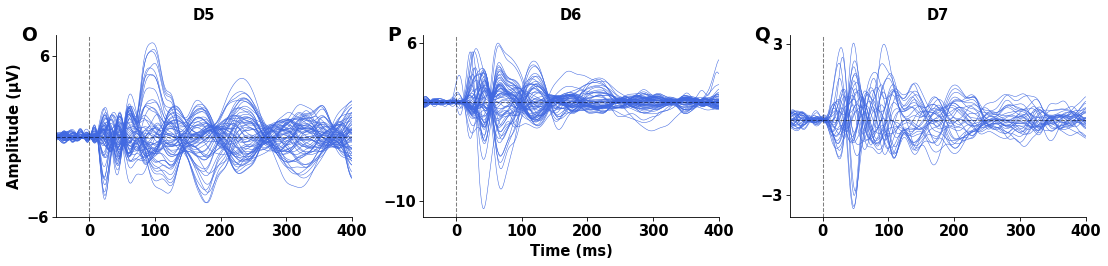

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

def round_to_five_or_ten(x):
    """Arrotonda a multipli di 5 o 10 per miglior leggibilità."""
    abs_x = abs(x)
    if abs_x <= 10:
        return np.sign(x) * (5 * round(abs_x / 5))
    else:
        return np.sign(x) * (10 * round(abs_x / 10))

panel_configs = [

    {
        "subject": "D5",
        "file_paths": [
          r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\F_G_wind_poly_lagrange_wind_poly_3\6.pkls\CE20_07_08_2019_000004_postICA_final.pkl",

        ]
    },
    {
        "subject": "D6",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\F_G_wind_poly_lagrange_wind_poly_3\6.pkls\CE17_18_07_19_000003_postICA_final.pkl",

        ]
    },
    {
        "subject": "D7",
        "file_paths": [
             r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\F_G_wind_poly_lagrange_wind_poly_3\6.pkls\prova_Mario_0003_postICA_final.pkl",

        ]
    },

]

import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

def round_to_five_or_ten(x):
    """Arrotonda a multipli di 5 o 10 per miglior leggibilità."""
    abs_x = abs(x)
    if abs_x <= 10:
        return np.sign(x) * (5 * round(abs_x / 5))
    else:
        return np.sign(x) * (10 * round(abs_x / 10))

panel_configs = [

    {
        "subject": "D5",
        "file_paths": [
          r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE20_07_08_2019_Session_4_LPrem_77\PAPER\F_G_wind_poly_lagrange_wind_poly_3\6.pkls\CE20_07_08_2019_000004_postICA_final.pkl",

        ]
    },
    {
        "subject": "D6",
        "file_paths": [
            r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\Chalfont\CE17_18_07_2019_Session_3_RMot_41\PAPER\F_G_wind_poly_lagrange_wind_poly_3\6.pkls\CE17_18_07_19_000003_postICA_final.pkl",

        ]
    },
    {
        "subject": "D7",
        "file_paths": [
             r"E:\Nuova cartella\OneDrive - Scuola Superiore Sant'Anna\dellXXX-laptop\temp_SSSP\PROJECTS\TMSPATH\DATI\MI_EXP\5.EBNeuro_cap+Brainamp+Nexstim\PAPER\F_G_wind_poly_lagrange_wind_poly_3\6.pkls\prova_Mario_0003_postICA_final.pkl",

        ]
    },

]

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

def round_to_five_or_ten(x):
    abs_x = abs(x)
    if abs_x <= 10:
        return np.sign(x) * (3 * round(abs_x / 3))
    else:
        return np.sign(x) * (10 * round(abs_x / 10))

color_line = 'royalblue'

# === FIGURA ===
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), sharey=False)
letters = ['O', 'P', 'Q']

for idx, config in enumerate(panel_configs):
    subject = config["subject"]
    file_path = config["file_paths"][0]
    ax = axes[idx]

    with open(file_path, 'rb') as f:
        data = pickle.load(f)

    data_array = data.get_data(copy=False)
    srate = data.info['sfreq']

    mean_data = np.mean(data_array, axis=0)
    times_ms = data.times * 1000
    mask = times_ms >= -50
    mean_data = mean_data[:, mask]
    times_ms = times_ms[mask]

    for ch in mean_data:
        ax.plot(times_ms, ch * 1e6, color=color_line, alpha=1, linewidth=0.5)

    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=.5)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=.5)

    ax.set_title(subject, y=1.05)
    ax.text(-0.12, 1.05, letters[idx], transform=ax.transAxes, fontsize=18, fontweight='bold', va='top', ha='left')

    y_vals = mean_data * 1e6
    y_min = round_to_five_or_ten(np.min(y_vals))
    y_max = round_to_five_or_ten(np.max(y_vals))
    ax.set_yticks([y_min, y_max])


    ax.set_xlim(times_ms[0], times_ms[-1])
    ax.set_xlabel("Time (ms)" if idx == 1 else "")
    if idx == 0:
        ax.set_ylabel("Amplitude (µV)")
    else:
        #ax.set_yticklabels([])
        ax.set_ylabel("")

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# === SALVATAGGIO ===
os.makedirs("./paperFigures", exist_ok=True)
fig.savefig("./paperFigures/Supporting_FigureC_rowICA.pdf", format="pdf", bbox_inches="tight", dpi=300)
fig.savefig("./paperFigures/Supporting_FigureC_rowICA.png", format="png", bbox_inches="tight", dpi=300)
fig.savefig("./paperFigures/Supporting_FigureC_rowICA.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()
